<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Machine Learning Project
MoraGarcia Carmen, (i don't know your last name) Léo, Dubouchet Chloé et Perrin Alicia


## Introduction

The data is taken from the KAGGLE competition website; it is the data set "Cardivascular Disease Risk
Prediction Dataset" available here: https://www.kaggle.com/datasets/bertnardomariouskono/cardiovasculardisease-risk-prediction-dataset.


This dataset contains 15,000 synthetic patient medical records specifically designed to predict the risk of
cardiovascular disease. Although synthetic, the data is generated using medical heuristics to ensure realistic
correlations between variables, such as the relationship between age, BMI, and blood pressure. The dataset
includes 19 variables for 15,000 patients.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimpy import skim

## 1. Exploratory data analysis

## a. Read the table of data

In [15]:
df = pd.read_csv("archive/healthcare_synthetic_data.csv", sep=",")

We start by checking the nature of the different variables and their encoding.

In [19]:
df['Gender'] = df['Gender'].astype('category')
df['Smoking_Status'] = df['Smoking_Status'].astype('category')
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].astype('category')
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].astype('category')
df['Family_History'] = df['Family_History'].astype('category')
df['Heart_Disease_Risk'] = df['Heart_Disease_Risk'].astype('category')
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                Categories                                       │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━━━┓                              │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables   ┃                              │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━━━┩                              │
│ │ Number of rows    │ 15000  │ │ int64       │ 9     │ │ Gender                  │                              │
│ │ Number of columns │ 19     │ │ category    │ 6     │ │ Smoking_Status          │                              │
│ └───────────────────┴────────┘ │ float64     │ 3     │ │ Alcohol_Consumption     │                              │
│                                │ string      │ 1     │ │ Physical_Activity_Level │                              │
│                                └─────────────┴───────┘ │ Family_History          │                              │
│                                                        │ Heart_Disease_Risk      │                              │
│                                                        └─────────────────────────┘                              │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                 ┃ NA  ┃ NA %  ┃ mean   ┃ sd     ┃ p0     ┃ p25    ┃ p50    ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Age                    │   0 │     0 │  54.54 │  11.88 │     25 │     46 │     55 │    63 │    85 │ ▁▅▇▇▅▁ │  │
│ │ Height_cm              │   0 │     0 │  165.3 │  9.186 │  138.5 │  158.5 │  164.7 │   172 │ 198.1 │  ▅▇▆▂  │  │
│ │ Weight_kg              │   0 │     0 │  75.25 │  14.11 │   33.7 │   65.2 │   73.9 │  83.9 │ 150.1 │  ▁▇▇▂  │  │
│ │ BMI                    │   0 │     0 │  27.45 │  4.135 │   14.5 │   24.5 │   27.2 │    30 │  46.1 │  ▅▇▃▁  │  │
│ │ Systolic_BP            │   0 │     0 │  135.1 │  11.26 │     90 │    127 │    135 │   143 │   182 │  ▂▇▇▁  │  │
│ │ Diastolic_BP           │   0 │     0 │  90.54 │  8.443 │     60 │     85 │     91 │    96 │   120 │  ▂▇▇▃  │  │
│ │ Cholesterol_Total      │   0 │     0 │  216.2 │  22.69 │    127 │    201 │    216 │   231 │   303 │  ▂▇▇▂  │  │
│ │ Cholesterol_LDL        │   0 │     0 │  140.4 │  17.91 │     70 │    128 │    140 │   152 │   210 │  ▂▇▇▂  │  │
│ │ Cholesterol_HDL        │   0 │     0 │  43.31 │  5.963 │     20 │     39 │     43 │    47 │    68 │  ▂▇▇▂  │  │
│ │ Fasting_Blood_Sugar    │   0 │     0 │  99.67 │  15.26 │     60 │     89 │     99 │   110 │   167 │  ▁▆▇▃  │  │
│ │ Stress_Level           │   0 │     0 │  5.504 │  2.874 │      1 │      3 │    5.5 │     8 │    10 │ ▇▃▇▃▇▇ │  │
│ │ Sleep_Hours            │   0 │     0 │  6.506 │  1.213 │      4 │      6 │      7 │     7 │    10 │ ▁▅▇▇▅▁ │  │
│ └────────────────────────┴─────┴───────┴────────┴────────┴────────┴────────┴────────┴───────┴───────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓  │
│ ┃ column                                        ┃ NA      ┃ NA %        ┃ ordered           ┃ unique         ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩  │
│ │ Gender                                        │       0 │           0 │ False             │              2 │  │
│ │ Smoking_Status                                │     

## b. Unidimensional descriptive analysis of the data.

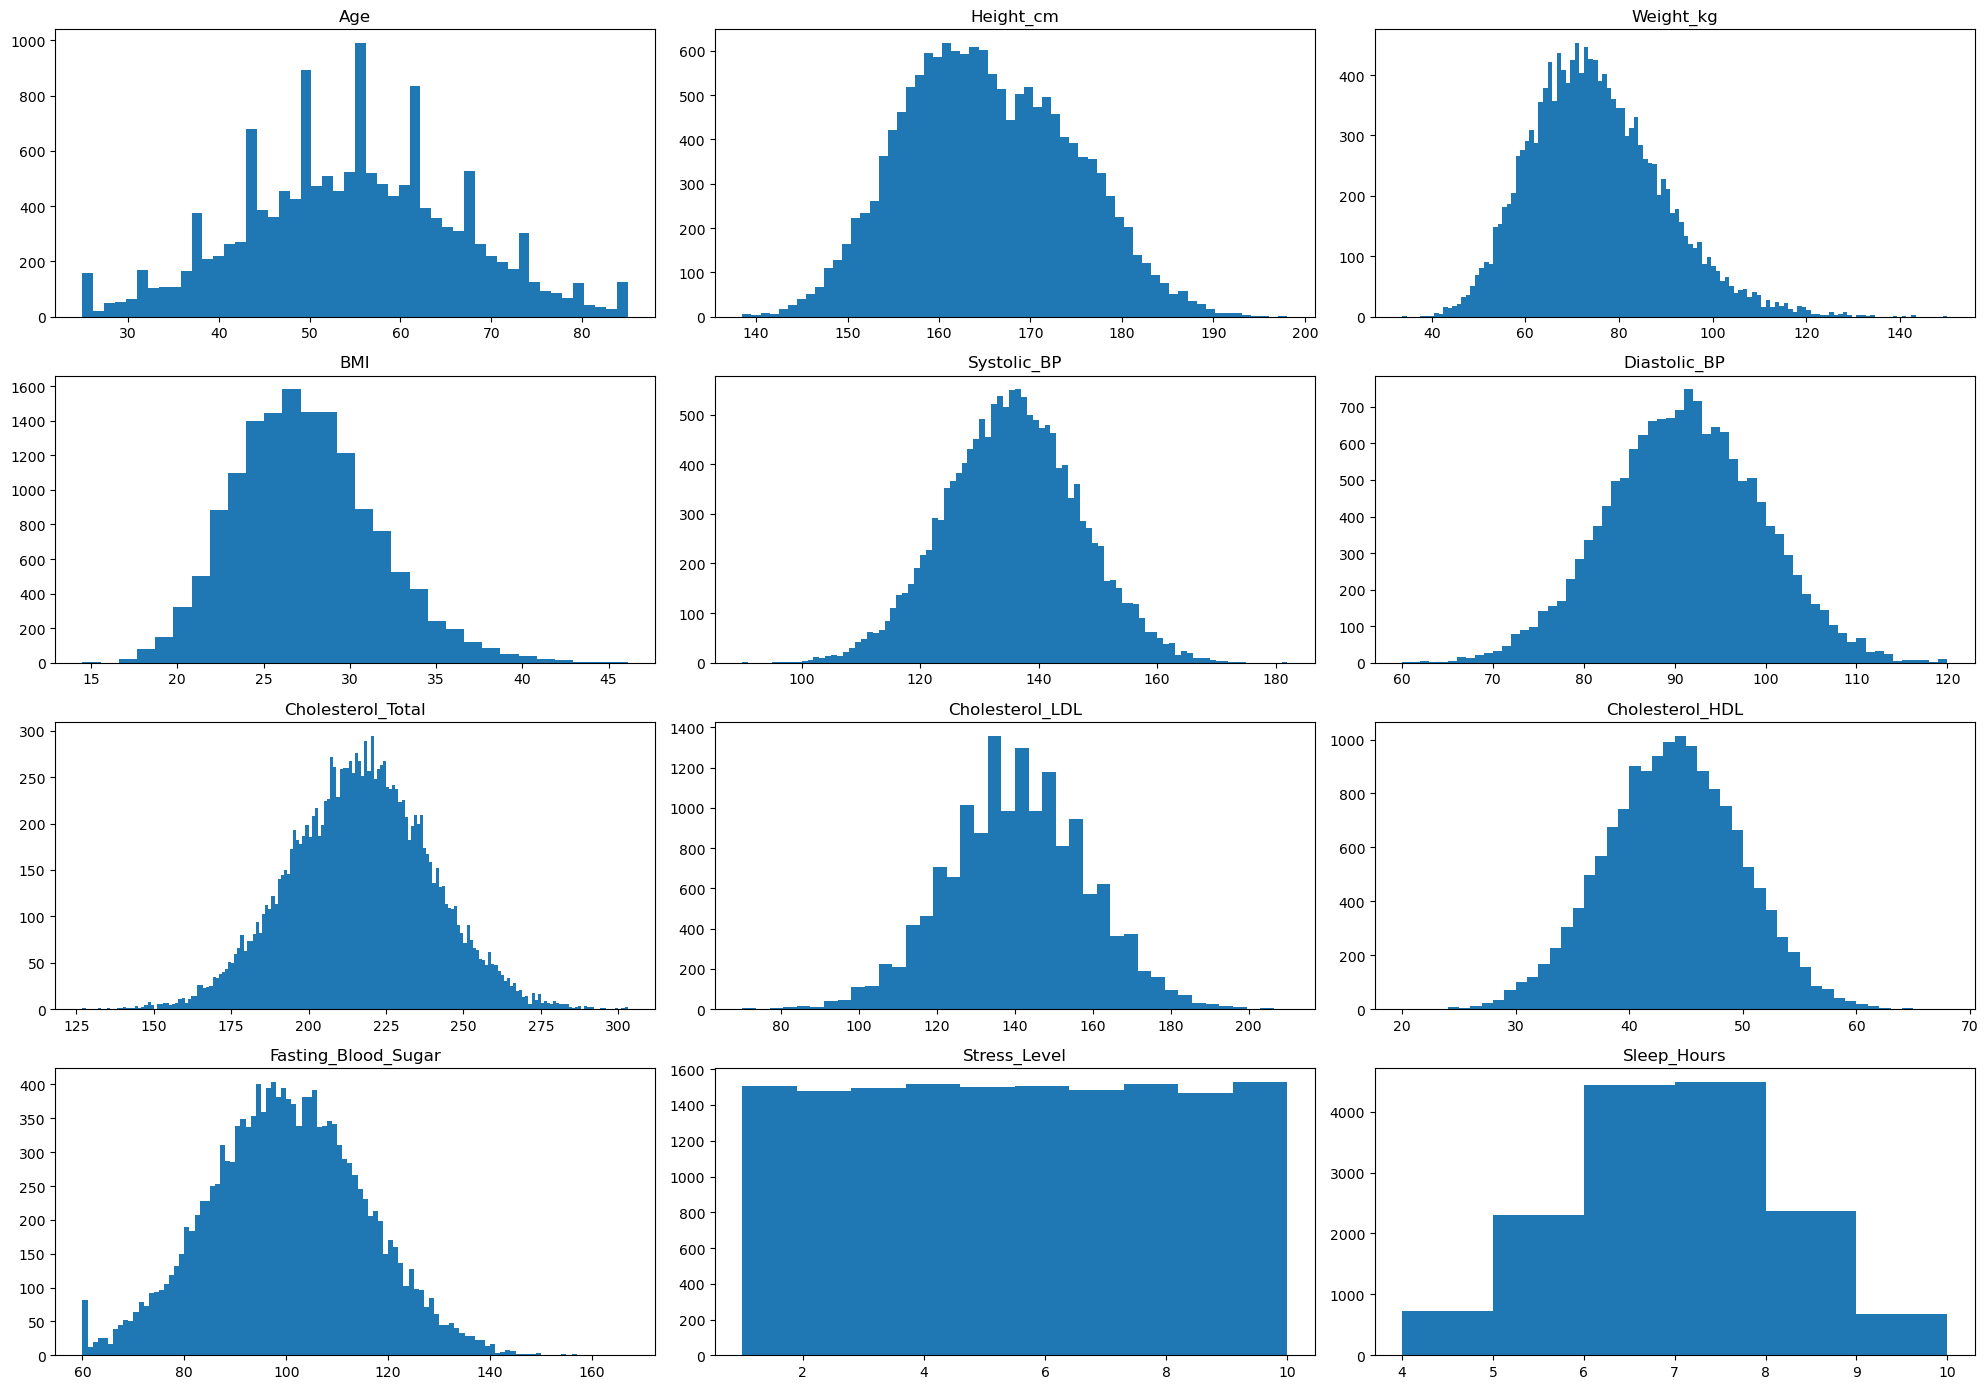

In [38]:
fig, axes = plt.subplots(4, 3, figsize=(20, 14))

axes[0, 0].hist(df["Age"], bins=50)
axes[0, 0].set_title("Age")
axes[0, 1].hist(df["Height_cm"], bins=60)
axes[0, 1].set_title("Height_cm")
axes[0, 2].hist(df["Weight_kg"], bins=120)
axes[0, 2].set_title("Weight_kg")
axes[1, 0].hist(df["BMI"], bins=30)
axes[1, 0].set_title("BMI")
axes[1, 1].hist(df["Systolic_BP"], bins=92)
axes[1, 1].set_title("Systolic_BP")
axes[1, 2].hist(df["Diastolic_BP"], bins=60)
axes[1, 2].set_title("Diastolic_BP")
axes[2, 0].hist(df["Cholesterol_Total"], bins=176)
axes[2, 0].set_title("Cholesterol_Total")
axes[2, 1].hist(df["Cholesterol_LDL"], bins=40)
axes[2, 1].set_title("Cholesterol_LDL")
axes[2, 2].hist(df["Cholesterol_HDL"], bins=48)
axes[2, 2].set_title("Cholesterol_HDL")
axes[3, 0].hist(df["Fasting_Blood_Sugar"], bins=107)
axes[3, 0].set_title("Fasting_Blood_Sugar")
axes[3, 1].hist(df["Stress_Level"], bins=10)
axes[3, 1].set_title("Stress_Level")
axes[3, 2].hist(df["Sleep_Hours"], bins=6)
axes[3, 2].set_title("Sleep_Hours")

plt.tight_layout()
plt.show()

Write here what we see

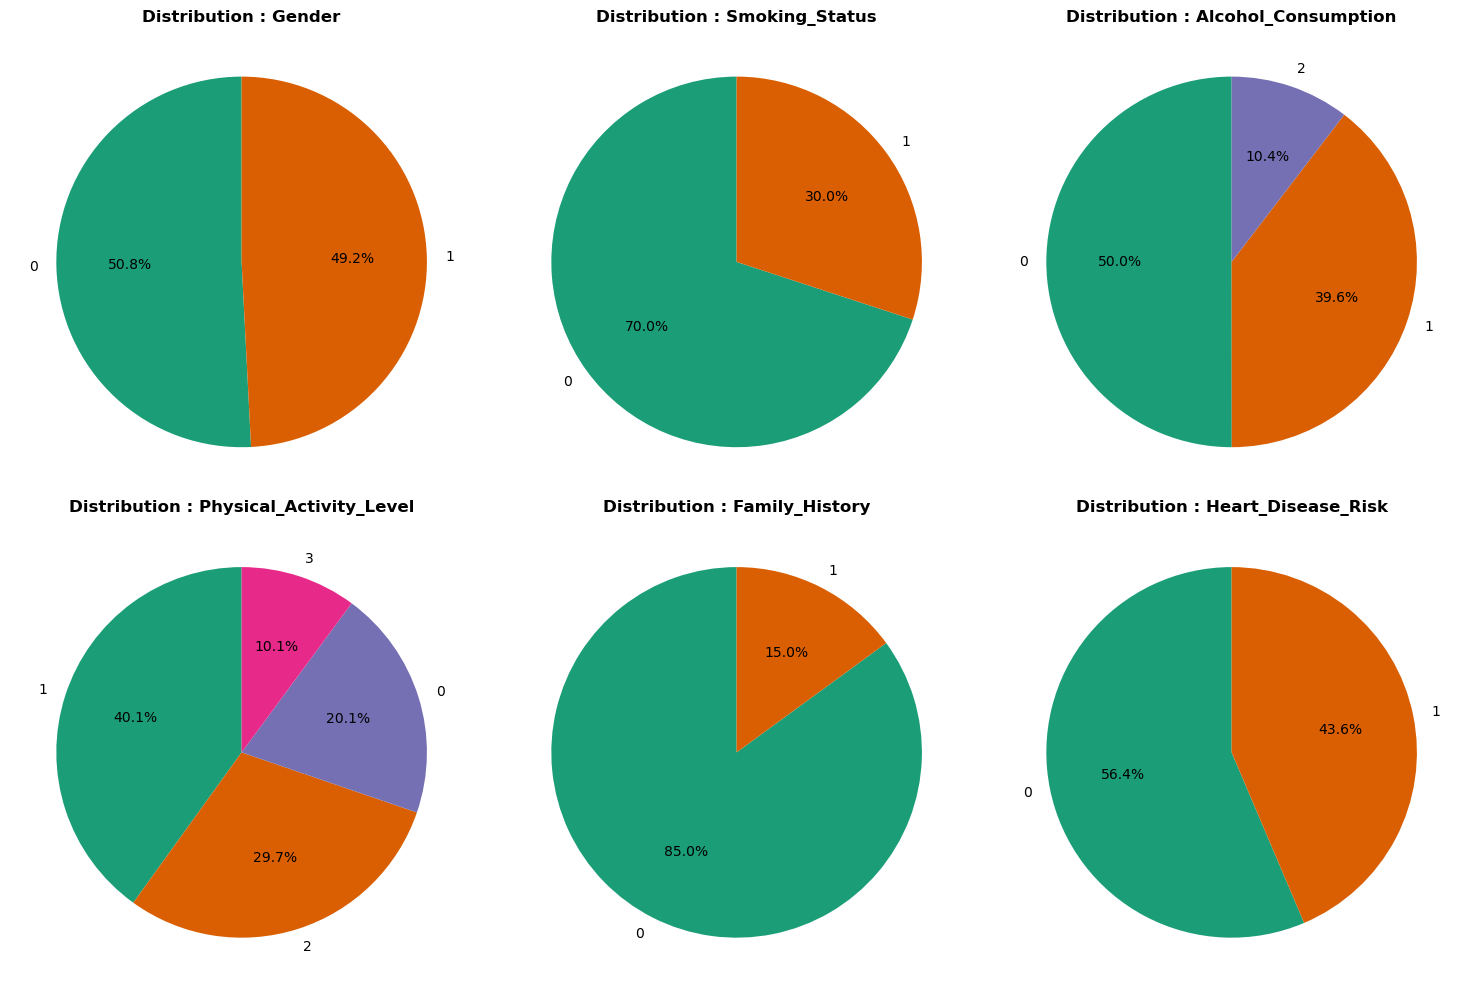

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

columns = [
    'Gender', 'Smoking_Status', 'Alcohol_Consumption', 
    'Physical_Activity_Level', 'Family_History', 'Heart_Disease_Risk'
]

axes_flat = axes.flatten()
cmap = plt.get_cmap('Dark2')

for i, col in enumerate(columns):
    counts = df[col].value_counts()
    colors = [cmap(i) for i in range(len(counts))]
    counts.plot(
        kind='pie', 
        ax=axes_flat[i], 
        autopct='%1.1f%%',
        colors=colors, 
        startangle=90,
        ylabel=''
    )
    axes_flat[i].set_title(f"Distribution : {col}", fontweight='bold')

plt.tight_layout()
plt.show()

## c. Bidimensional descriptive analysis of the data.